In [1]:
import os
import sys
import shutil
import zipfile
import yaml
from pathlib import Path
import glob

import torch
from tqdm.auto import tqdm          
import ultralytics
from ultralytics import YOLO
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import cv2
import random
from IPython.display import Image as IPImage, display

%matplotlib inline

print(f"Ultralytics version: {ultralytics.__version__}")

Ultralytics version: 8.4.22


In [3]:
ARCHIVES_DIR = Path("YoloDatasets")          
READY_DIR = Path("YoloDatasetReady")         
TEMP_EXTRACT_DIR = Path("temp_extract")      

READY_DIR.mkdir(parents=True, exist_ok=True)
TEMP_EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

(READY_DIR / "images").mkdir(exist_ok=True)
(READY_DIR / "labels").mkdir(exist_ok=True)

In [4]:
def find_images_and_labels(root_path):
    pairs = []
    root = Path(root_path)
    
    image_patterns = ["*.jpg", "*.jpeg", "*.png", "*.bmp", "*.tiff", "*.tif"]
    for pattern in image_patterns:
        for img_path in root.rglob(pattern):
            img_path = Path(img_path)
            img_stem = img_path.stem
            
            rel_path = img_path.relative_to(root)
            rel_dir = rel_path.parent
            
            possible_label_paths = [
                img_path.parent / f"{img_stem}.txt",
                root / "labels" / "train" / f"{img_stem}.txt",
                root / "labels" / f"{img_stem}.txt",
            ]
            
            if rel_dir.parts and rel_dir.parts[0] == "images":
                label_subdir = rel_dir.relative_to("images")
                possible_label_paths.extend([
                    root / "labels" / label_subdir / f"{img_stem}.txt",
                    root / "labels" / "train" / label_subdir / f"{img_stem}.txt",
                ])
            
            label_path = None
            for p in possible_label_paths:
                if p.exists():
                    label_path = p
                    break
            
            if label_path:
                pairs.append((img_path, label_path))
    
    return pairs

In [5]:
archives = list(ARCHIVES_DIR.glob("*.zip"))
if not archives:
    print(f"Архивы не найдены")
else:
    print(f"Найдено архивов: {len(archives)}")
    for arch in archives:
        print(f"   - {arch.name}")

Найдено архивов: 5
   - job18YOLOImages.zip
   - job39YOLOImages.zip
   - job40YOLOImages.zip
   - job42YOLOImages.zip
   - job48YOLOImages.zip


In [6]:
import re

def sanitize_filename(name):
    return re.sub(r'[^\w\-_\.]', '_', name)

all_classes = set()
total_images_copied = 0
train_txt_content = []

(READY_DIR / "images").mkdir(parents=True, exist_ok=True)
(READY_DIR / "labels").mkdir(parents=True, exist_ok=True)

for archive_path in tqdm(archives, desc="Распаковка архивов"):
    if TEMP_EXTRACT_DIR.exists():
        shutil.rmtree(TEMP_EXTRACT_DIR)
    TEMP_EXTRACT_DIR.mkdir(parents=True)
    
    with zipfile.ZipFile(archive_path, 'r') as zip_ref:
        zip_ref.extractall(TEMP_EXTRACT_DIR)
    
    yaml_path = TEMP_EXTRACT_DIR / "data.yaml"
    if yaml_path.exists():
        with open(yaml_path, 'r', encoding='utf-8') as f:
            data_cfg = yaml.safe_load(f)
            if "names" in data_cfg:
                if isinstance(data_cfg["names"], list):
                    all_classes.update(data_cfg["names"])
                elif isinstance(data_cfg["names"], dict):
                    all_classes.update(data_cfg["names"].values())
    
    pairs = find_images_and_labels(TEMP_EXTRACT_DIR)
    
    if not pairs:
        print(f"⚠️ В архиве {archive_path.name} не найдено пар изображение‑метка.")
        continue
    
    for img_src, lbl_src in pairs:
        img_src = Path(img_src).resolve()
        lbl_src = Path(lbl_src).resolve()
        
        if not img_src.exists():
            print(f"Исходное изображение не найдено: {img_src}")
            continue
        if not lbl_src.exists():
            print(f"Исходная метка не найдена: {lbl_src}")
            continue
        
        archive_prefix = sanitize_filename(archive_path.stem)[:30]
        clean_stem = sanitize_filename(img_src.stem)
        new_stem = f"{archive_prefix}_{clean_stem}"
        
        img_dst = READY_DIR / "images" / f"{new_stem}{img_src.suffix}"
        lbl_dst = READY_DIR / "labels" / f"{new_stem}.txt"
        
        try:
            shutil.copy2(str(img_src), str(img_dst))
            shutil.copy2(str(lbl_src), str(lbl_dst))
            train_txt_content.append(str(img_dst.resolve()))
            total_images_copied += 1
        except Exception as e:
            print(f"Ошибка копирования {img_src.name}: {e}")
            continue
    
    print(f"{archive_path.name}: скопировано {len(pairs)} пар (успешно: {total_images_copied - sum(1 for _ in train_txt_content)})")

print(f"\nВсего скопировано {total_images_copied} изображений в {READY_DIR}")

Распаковка архивов:   0%|          | 0/5 [00:00<?, ?it/s]

job18YOLOImages.zip: скопировано 521 пар (успешно: 0)
job39YOLOImages.zip: скопировано 1764 пар (успешно: 0)
job40YOLOImages.zip: скопировано 805 пар (успешно: 0)
job42YOLOImages.zip: скопировано 506 пар (успешно: 0)
job48YOLOImages.zip: скопировано 3889 пар (успешно: 0)

Всего скопировано 7485 изображений в YoloDatasetReady


In [7]:
train_txt_path = READY_DIR / "train.txt"
train_txt_path.write_text("\n".join(train_txt_content), encoding="utf-8")

1055700

In [8]:
if all_classes:
    class_names = sorted(list(all_classes))
    class_dict = {i: name for i, name in enumerate(class_names)}
else:
    class_dict = {0: "object"}
    print("Имена классов не найдены в data.yaml. Используется заглушка 'object'.")

data_yaml_content = {
    "path": str(READY_DIR.resolve()),
    "train": "images",          
    "val": "images",            
    "names": class_dict
}

data_yaml_path = READY_DIR / "data.yaml"
with open(data_yaml_path, 'w') as f:
    yaml.dump(data_yaml_content, f, default_flow_style=False, allow_unicode=True)

print(f"data.yaml создан:\n{data_yaml_path.read_text()}")
print(f"Количество классов: {len(class_dict)}")

data.yaml создан:
names:
  0: garbage_can
  1: kgo_empty
  2: kgo_full
  3: kgo_platform
path: C:\games\!!!studyMaga\2026\PPGarbageGit\Project_Urfu_2026\datasetCreation\YoloDatasetReady
train: images
val: images

Количество классов: 4


In [9]:
cuda_available = torch.cuda.is_available()
device = torch.device("cuda" if cuda_available else "cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA доступна: {cuda_available}")

PyTorch version: 2.10.0+cu128
CUDA доступна: True


In [10]:
model = YOLO("yolo26n.pt")

results = model.train(
    data=str(data_yaml_path),  
    epochs=50,                 
    patience=8,                
    imgsz=320,                 
    batch=32,                  
    device=device.type,        
    workers=8,                 
    project="runs/train",      
    name="yolo26n_custom",     
    exist_ok=True,             
    pretrained=True,           
    optimizer="auto",          
    amp=False,                 
    cache=True,                
    verbose=False,             
    seed=42                    
)

print("Обучение завершено")

New https://pypi.org/project/ultralytics/8.4.37 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.22  Python-3.10.6 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5070, 12227MiB)
engine\trainer: agnostic_nms=False, amp=False, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=YoloDatasetReady\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo26n_

In [11]:
train_runs_dir = Path("runs/detect/runs/train/")
exp_dirs = sorted(train_runs_dir.glob("yolo26n*"), key=os.path.getmtime)

if not exp_dirs:
    raise FileNotFoundError("Не найдено ни одной папки эксперимента yolo26n* в runs/train/")

exp_dir = exp_dirs[-1]  
print(f"Папка эксперимента: {exp_dir.resolve()}")

results_csv = exp_dir / "results.csv"
if results_csv.exists():
    df = pd.read_csv(results_csv)
    df.columns = df.columns.str.strip()
    print(f"📊 Загружено {len(df)} эпох метрик")
    display(df.tail())
else:
    print("Файл results.csv не найден")

Папка эксперимента: C:\games\!!!studyMaga\2026\PPGarbageGit\Project_Urfu_2026\datasetCreation\runs\detect\runs\train\yolo26n_custom
📊 Загружено 50 эпох метрик


,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
45,46,2220.55,1.10292,0.44540,0.01623,0.96243,0.61885,0.71911,0.51656,1.06255,0.40493,0.01815,0.000136,0.000136,0.000136
46,47,2264.33,1.09370,0.44031,0.01605,0.96468,0.61753,0.81894,0.57850,1.06165,0.40311,0.01815,0.000111,0.000111,0.000111
47,48,2309.44,1.08428,0.43795,0.01597,0.95986,0.62234,0.81928,0.57838,1.05753,0.39948,0.01803,0.000087,0.000087,0.000087
48,49,2354.34,1.08108,0.43721,0.01576,0.96280,0.61904,0.81913,0.59600,1.05193,0.40151,0.01795,0.000062,0.000062,0.000062
49,50,2400.42,1.07640,0.43314,0.01569,0.96158,0.62159,0.98522,0.71243,1.05210,0.39846,0.01791,0.000037,0.000037,0.000037


C:\Users\Александр\AppData\Local\Temp\ipykernel_2916\3710549327.py:68: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Александр\AppData\Local\Temp\ipykernel_2916\3710549327.py:70: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=150, bbox_inches='tight')
c:\games\!!!studyMaga\2026\PPGarbageGit\Project_Urfu_2026\venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


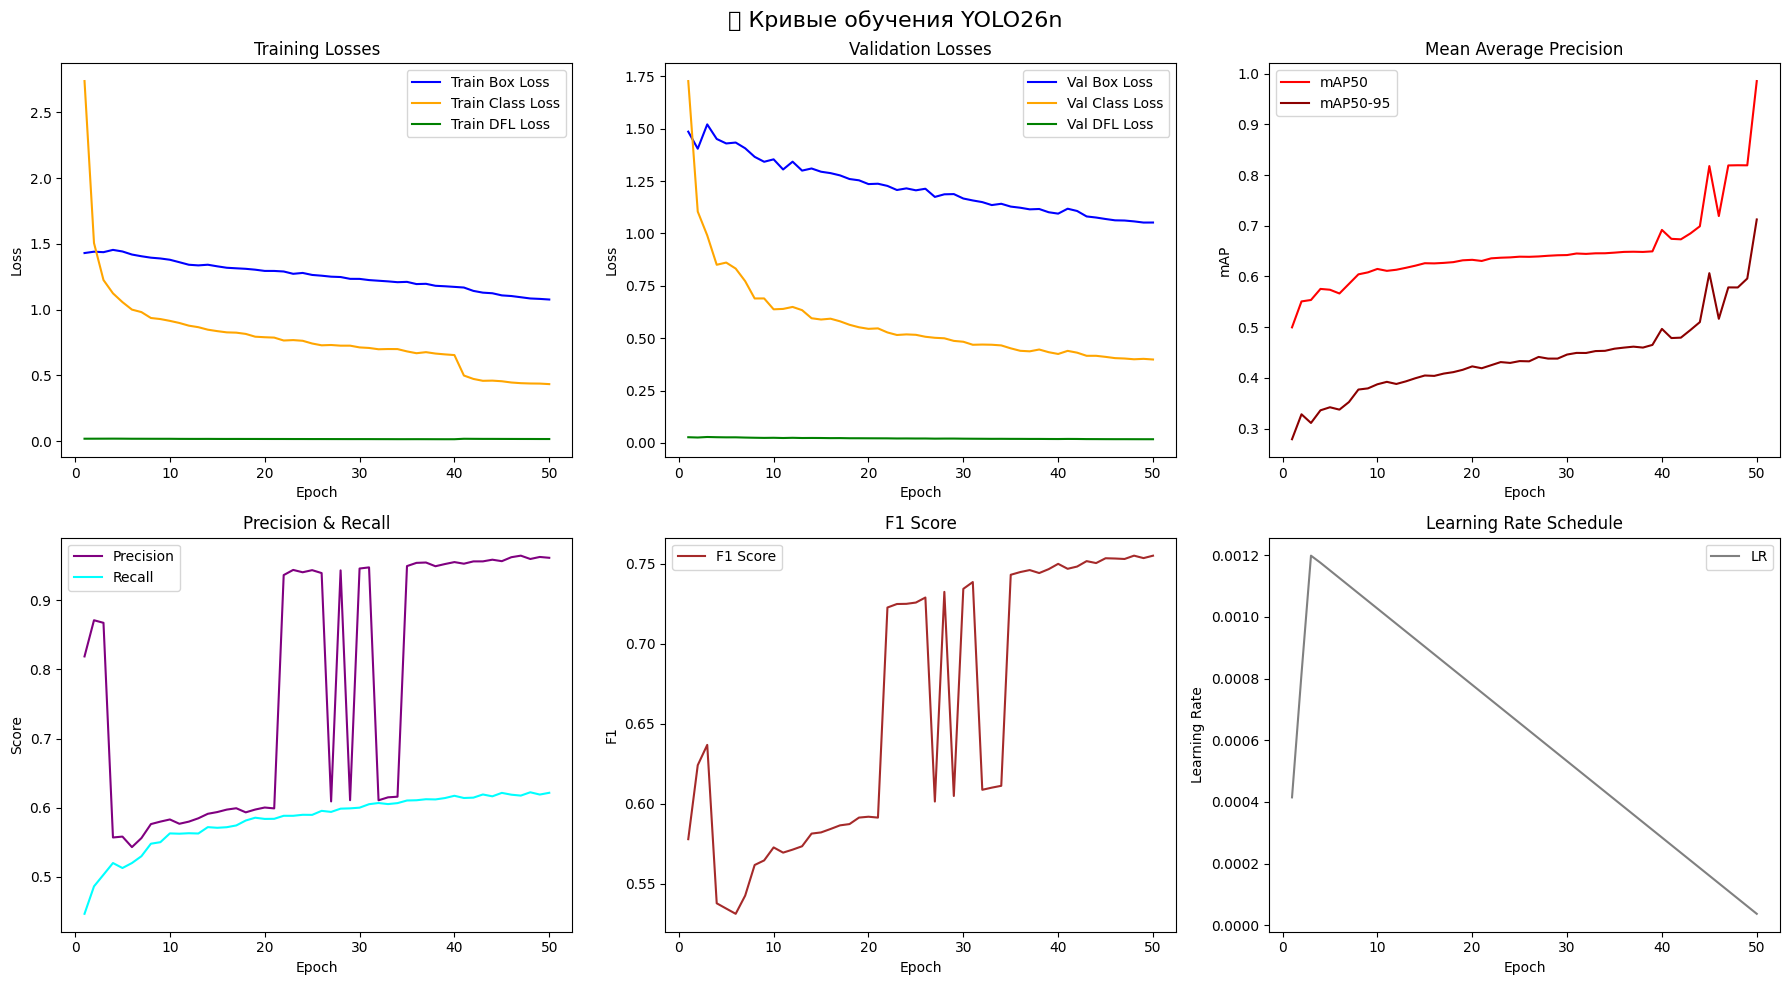

In [12]:
def plot_training_curves(df, save_path=None):
    epochs = df.index + 1
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle("📈 Кривые обучения YOLO26n", fontsize=16)
    
    # Losses
    if 'train/box_loss' in df.columns:
        axes[0,0].plot(epochs, df['train/box_loss'], label='Train Box Loss', color='blue')
    if 'train/cls_loss' in df.columns:
        axes[0,0].plot(epochs, df['train/cls_loss'], label='Train Class Loss', color='orange')
    if 'train/dfl_loss' in df.columns:
        axes[0,0].plot(epochs, df['train/dfl_loss'], label='Train DFL Loss', color='green')
    axes[0,0].set_xlabel('Epoch')
    axes[0,0].set_ylabel('Loss')
    axes[0,0].legend()
    axes[0,0].set_title('Training Losses')
    
    # Validation Losses
    if 'val/box_loss' in df.columns:
        axes[0,1].plot(epochs, df['val/box_loss'], label='Val Box Loss', color='blue')
    if 'val/cls_loss' in df.columns:
        axes[0,1].plot(epochs, df['val/cls_loss'], label='Val Class Loss', color='orange')
    if 'val/dfl_loss' in df.columns:
        axes[0,1].plot(epochs, df['val/dfl_loss'], label='Val DFL Loss', color='green')
    axes[0,1].set_xlabel('Epoch')
    axes[0,1].set_ylabel('Loss')
    axes[0,1].legend()
    axes[0,1].set_title('Validation Losses')
    
    # mAP
    if 'metrics/mAP50(B)' in df.columns:
        axes[0,2].plot(epochs, df['metrics/mAP50(B)'], label='mAP50', color='red')
    if 'metrics/mAP50-95(B)' in df.columns:
        axes[0,2].plot(epochs, df['metrics/mAP50-95(B)'], label='mAP50-95', color='darkred')
    axes[0,2].set_xlabel('Epoch')
    axes[0,2].set_ylabel('mAP')
    axes[0,2].legend()
    axes[0,2].set_title('Mean Average Precision')
    
    # Precision & Recall
    if 'metrics/precision(B)' in df.columns:
        axes[1,0].plot(epochs, df['metrics/precision(B)'], label='Precision', color='purple')
    if 'metrics/recall(B)' in df.columns:
        axes[1,0].plot(epochs, df['metrics/recall(B)'], label='Recall', color='cyan')
    axes[1,0].set_xlabel('Epoch')
    axes[1,0].set_ylabel('Score')
    axes[1,0].legend()
    axes[1,0].set_title('Precision & Recall')
    
    # F1 Score (вычисляем, если есть precision и recall)
    if 'metrics/precision(B)' in df.columns and 'metrics/recall(B)' in df.columns:
        f1 = 2 * (df['metrics/precision(B)'] * df['metrics/recall(B)']) / (df['metrics/precision(B)'] + df['metrics/recall(B)'] + 1e-16)
        axes[1,1].plot(epochs, f1, label='F1 Score', color='brown')
        axes[1,1].set_xlabel('Epoch')
        axes[1,1].set_ylabel('F1')
        axes[1,1].legend()
        axes[1,1].set_title('F1 Score')
    
    # Learning Rate
    if 'lr/pg0' in df.columns:
        axes[1,2].plot(epochs, df['lr/pg0'], label='LR', color='gray')
        axes[1,2].set_xlabel('Epoch')
        axes[1,2].set_ylabel('Learning Rate')
        axes[1,2].legend()
        axes[1,2].set_title('Learning Rate Schedule')
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

if results_csv.exists():
    plot_training_curves(df, save_path=exp_dir / "training_curves_custom.png")
else:
    print("Нет данных для построения графиков.")

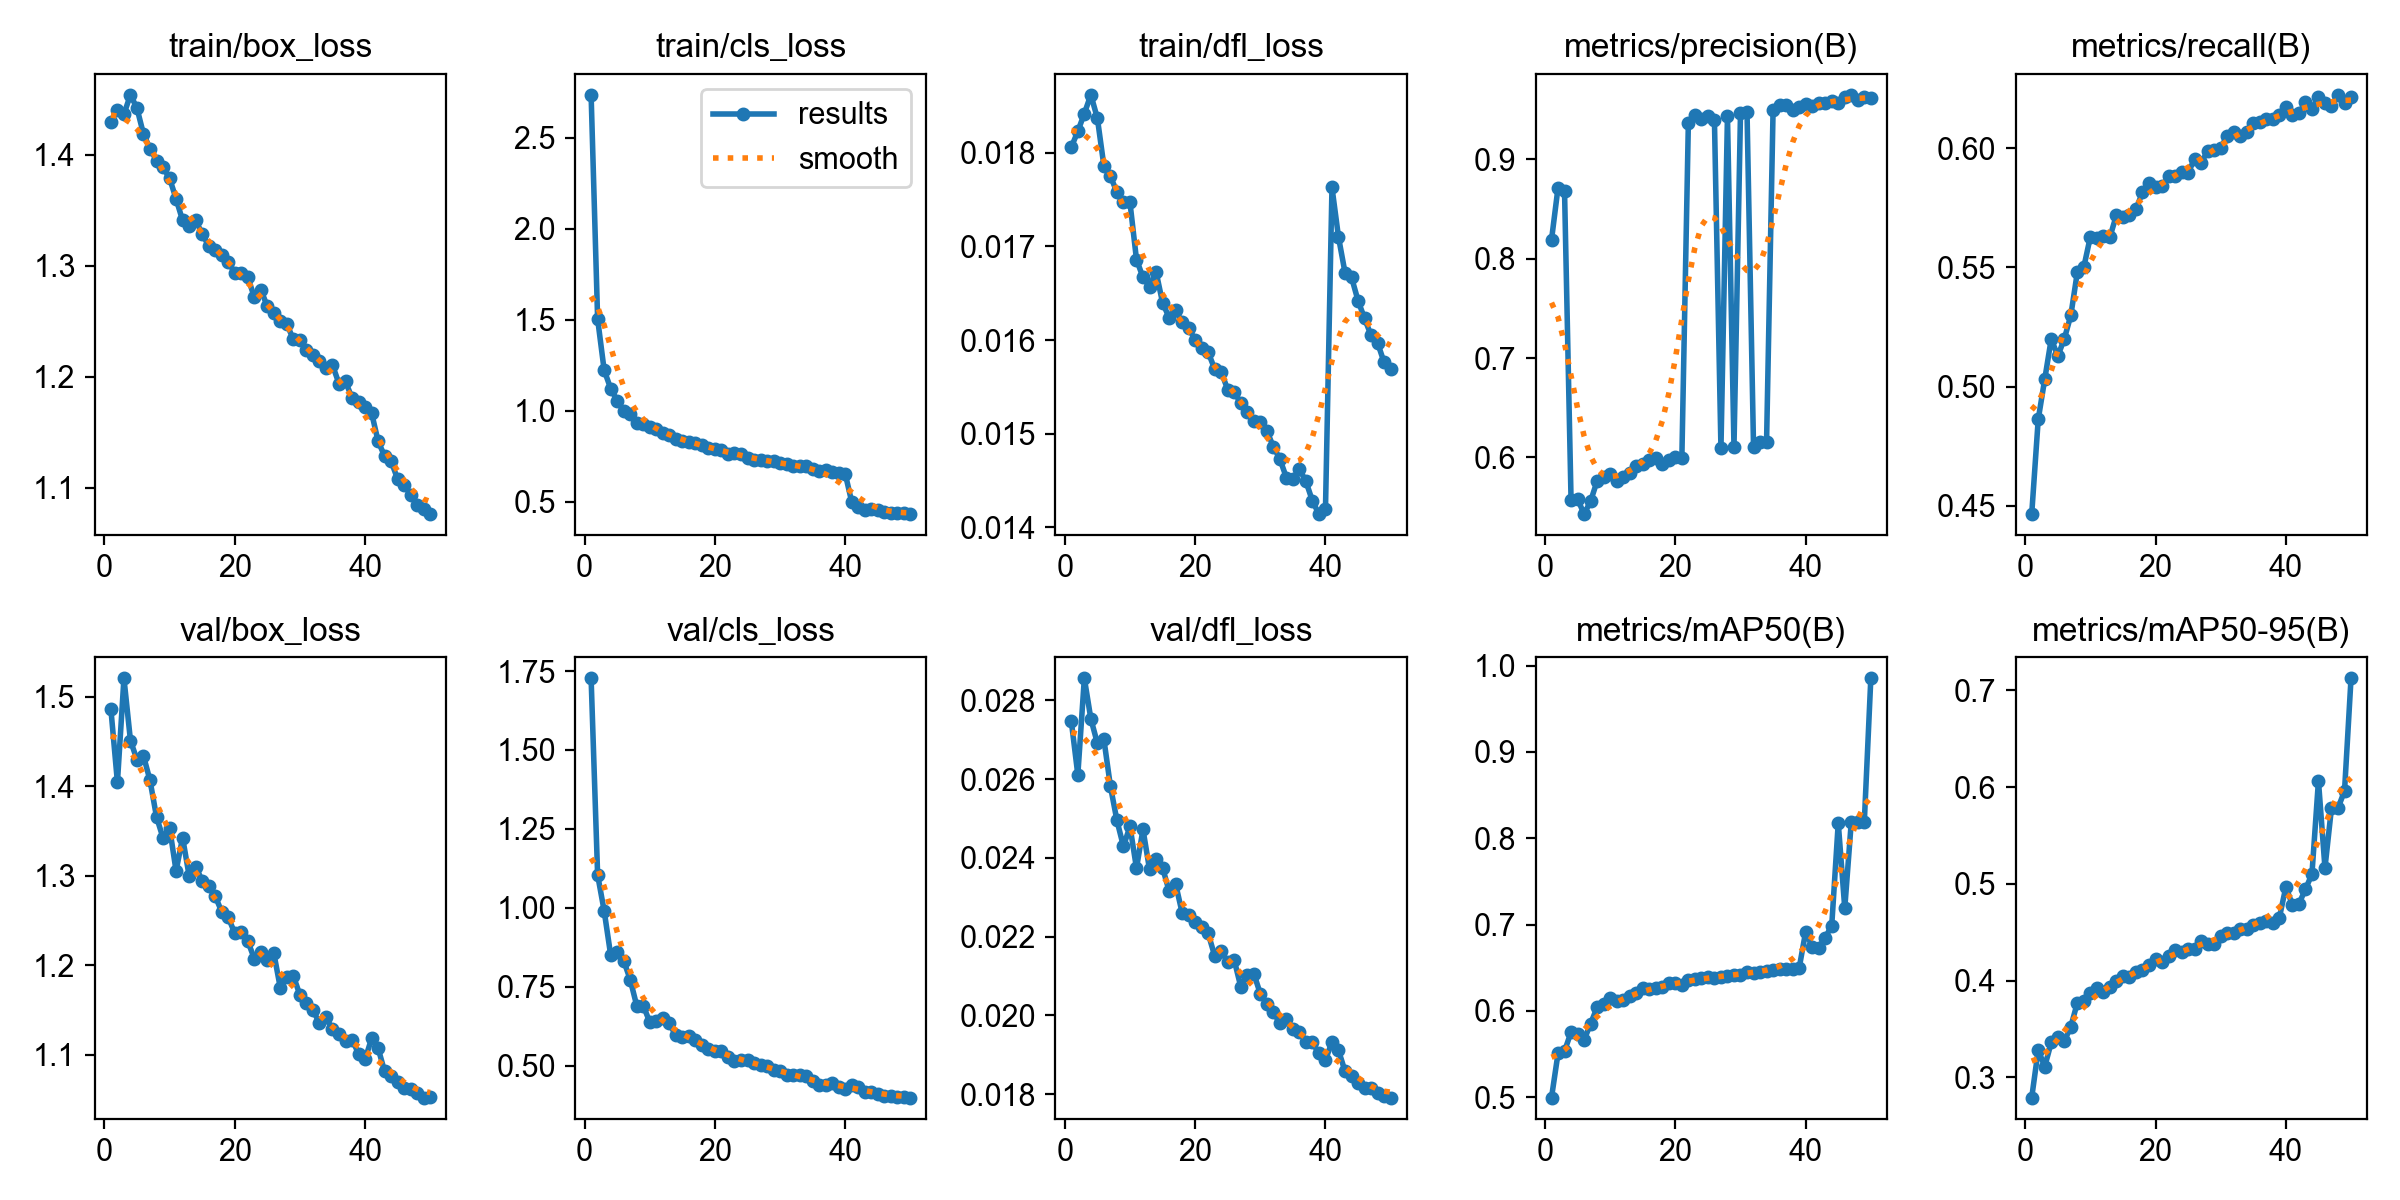

In [13]:
if (exp_dir / "results.png").exists():
    display(IPImage(filename=str(exp_dir / "results.png")))
else:
    print("Стандартный график results.png не найден.")

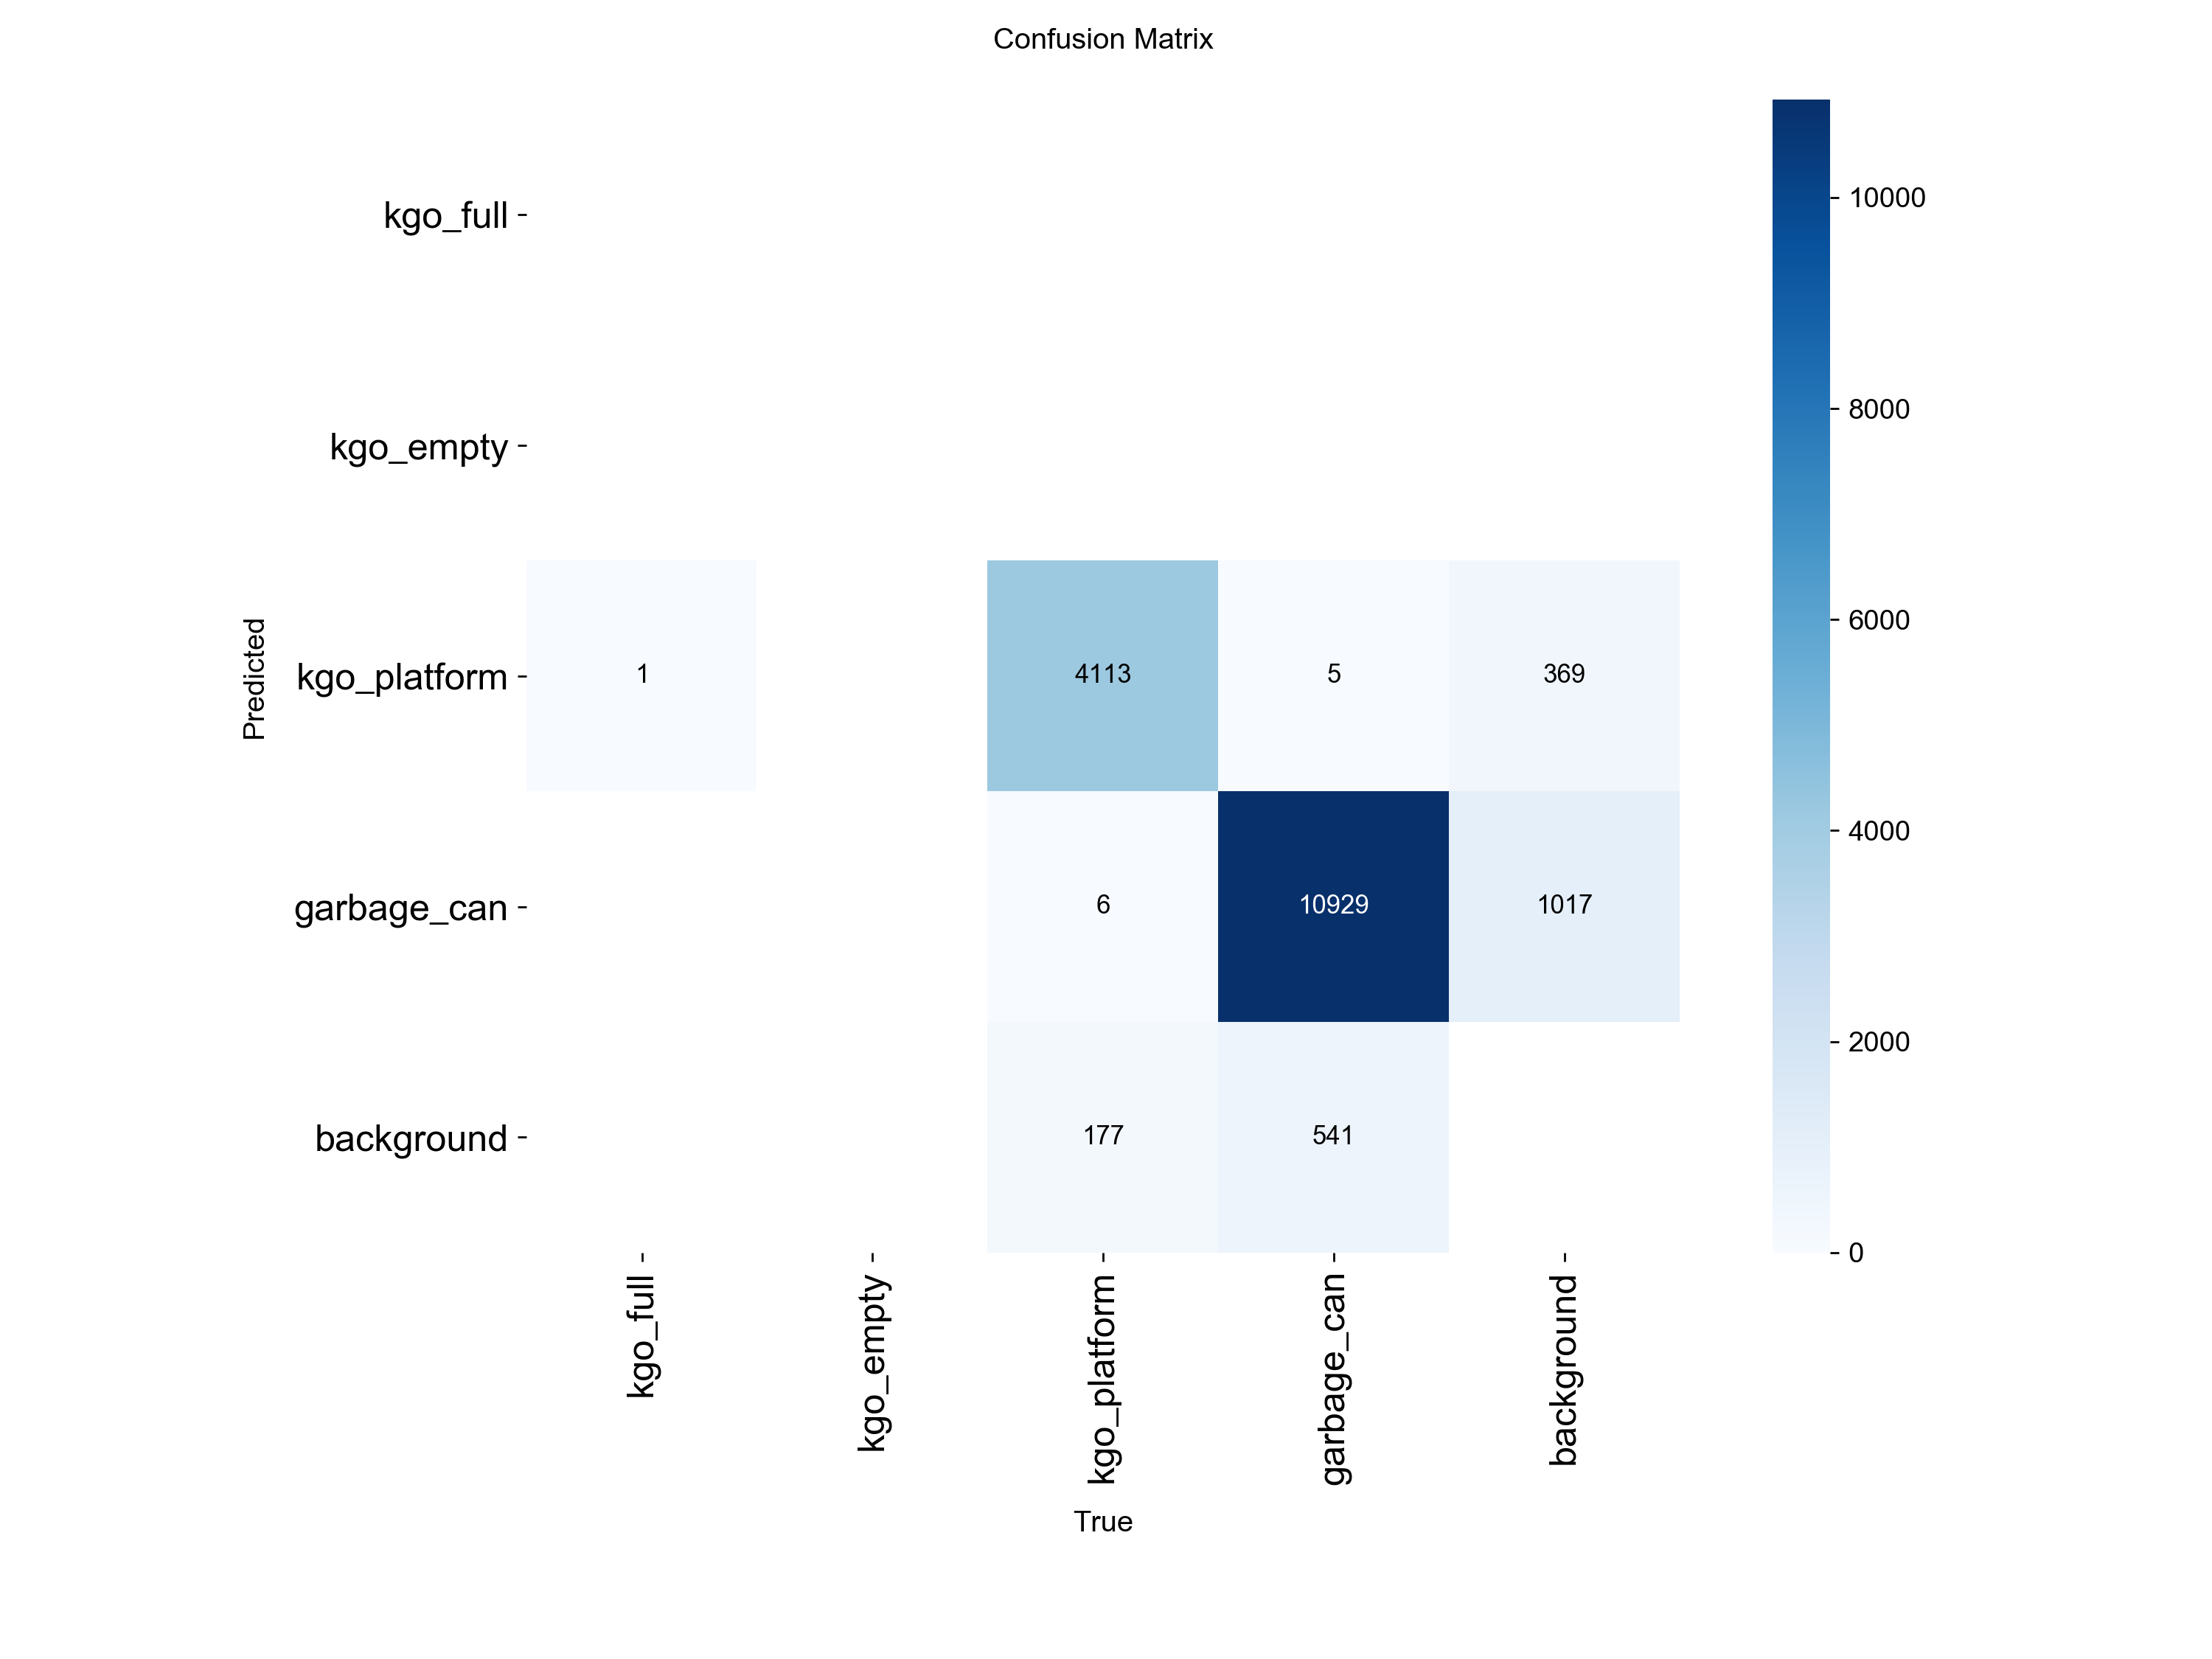

In [14]:
cm_path = exp_dir / "confusion_matrix.png"
if cm_path.exists():
    display(IPImage(filename=str(cm_path)))
else:
    print("Матрица ошибок не найдена (возможно, валидация не проводилась).")

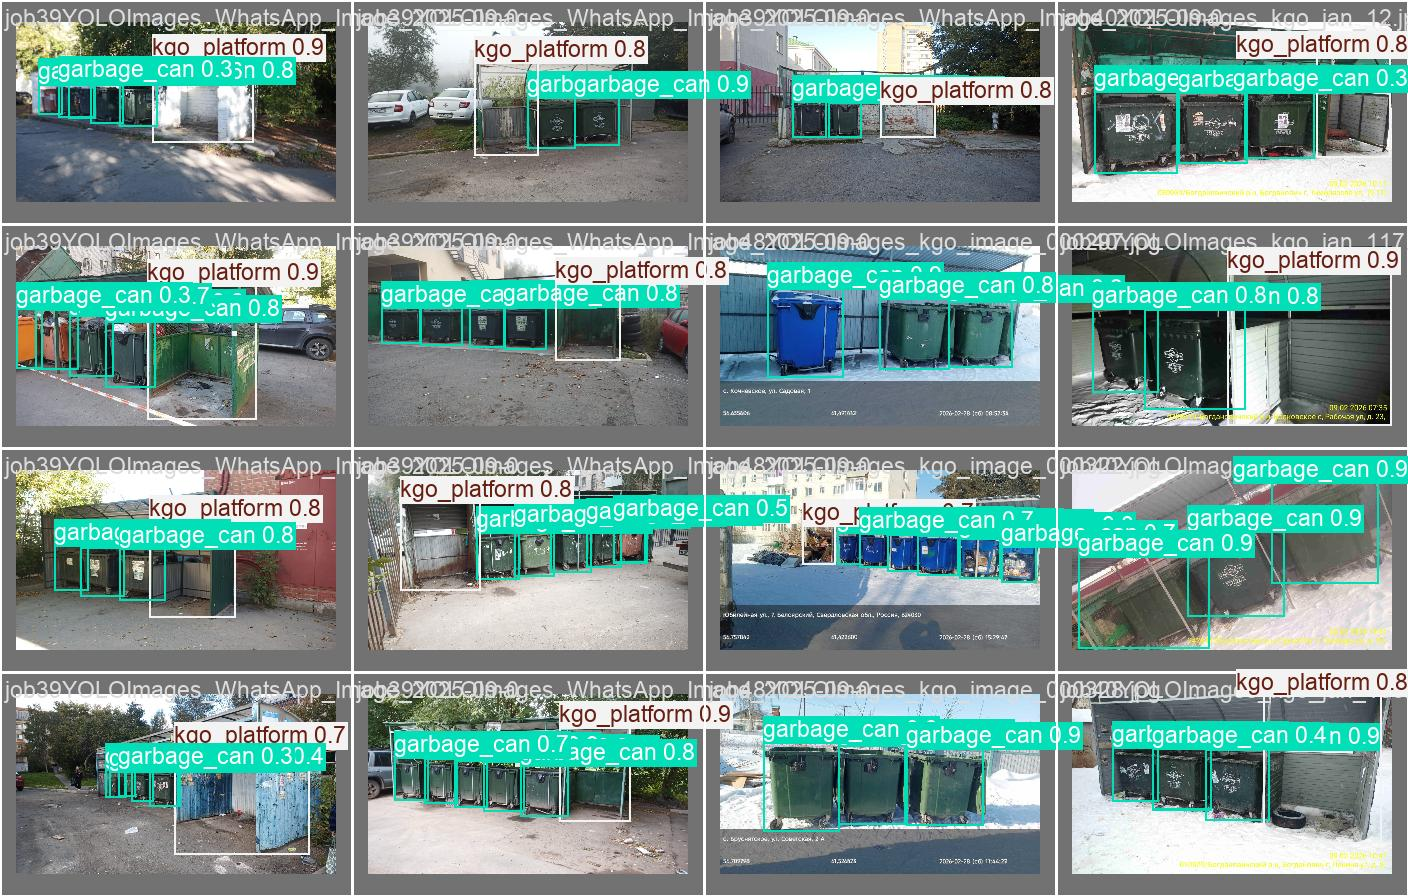

In [15]:
val_batch_path = exp_dir / "val_batch0_pred.jpg"
if val_batch_path.exists():
    display(IPImage(filename=str(val_batch_path)))
else:
    print("Изображения с предсказаниями не найдены.")

In [17]:
best_model_path = exp_dir / "weights" / "best.pt"
if best_model_path.exists():
    model = YOLO(str(best_model_path))
    metrics = model.val(data=str(data_yaml_path), split='val')
    print("\nФинальные метрики:")
    print(f"mAP50:      {metrics.box.map50:.4f}")
    print(f"mAP50-95:   {metrics.box.map:.4f}")
    print(f"Precision:  {metrics.box.mp:.4f}")
    print(f"Recall:     {metrics.box.mr:.4f}")
else:
    print("Файл best.pt не найден")

Ultralytics 8.4.22  Python-3.10.6 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5070, 12227MiB)
YOLO26n summary (fused): 122 layers, 2,375,616 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 787.5342.2 MB/s, size: 167.3 KB)
val: Scanning C:\games\!!!studyMaga\2026\PPGarbageGit\Project_Urfu_2026\datasetCreation\YoloDatasetReady\labels.cache... 7485 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 7485/7485  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 468/468 17.8it/s 26.3s<0.1s
                   all       7485      15772      0.964      0.619      0.985      0.713
              kgo_full          1          1          1          0      0.995      0.697
          kgo_platform       4273       4296      0.946      0.938      0.984      0.744
           garbage_can       5364      11475      0.945       0.92      0.976      0.697
Speed: 0.2ms preprocess, 0.6ms inference, 0.0ms loss, 


image 1/1 c:\games\!!!studyMaga\2026\PPGarbageGit\Project_Urfu_2026\datasetCreation\YoloDatasetReady\images\job48YOLOImages_2026-03-11_000243.jpg: 320x192 1 garbage_can, 36.3ms
Speed: 2.0ms preprocess, 36.3ms inference, 11.1ms postprocess per image at shape (1, 3, 320, 192)


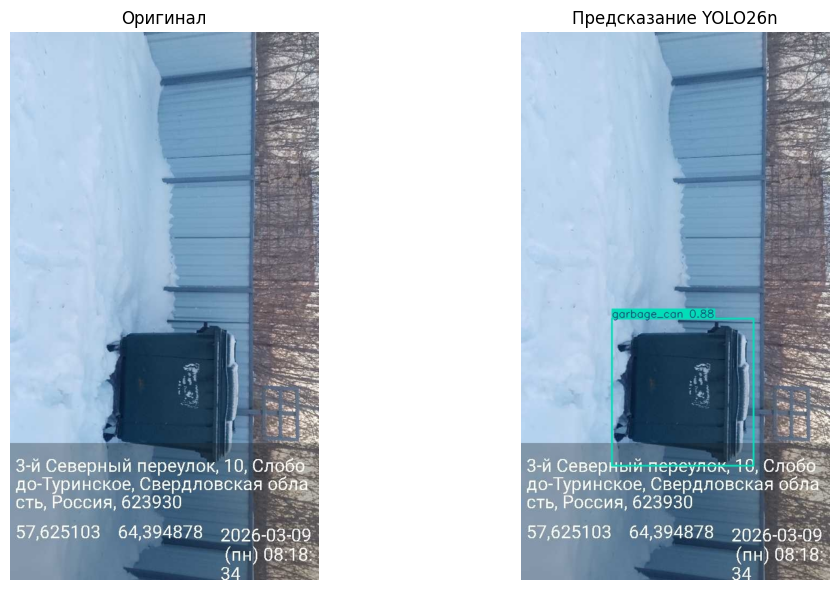


image 1/1 c:\games\!!!studyMaga\2026\PPGarbageGit\Project_Urfu_2026\datasetCreation\YoloDatasetReady\images\job40YOLOImages_kgo_jan_135.jpg: 320x192 1 kgo_platform, 12.9ms
Speed: 1.9ms preprocess, 12.9ms inference, 0.9ms postprocess per image at shape (1, 3, 320, 192)


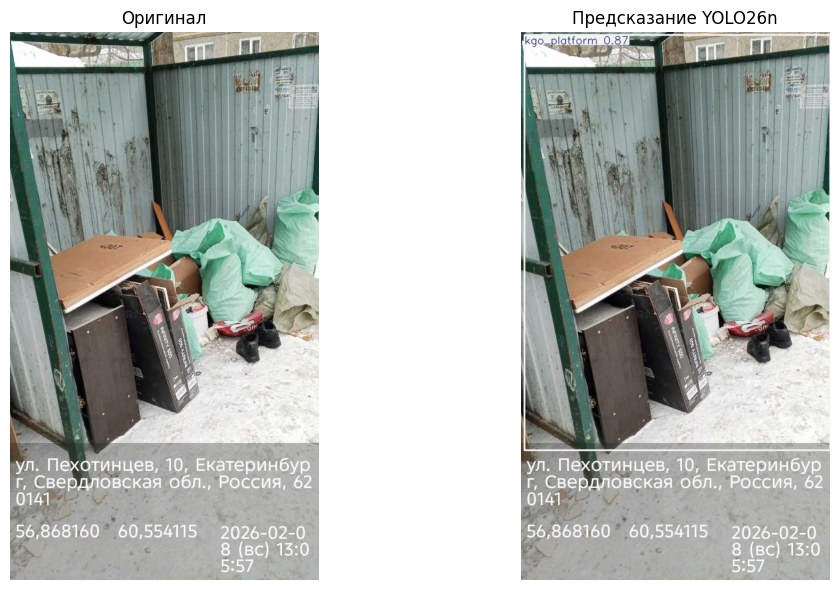


image 1/1 c:\games\!!!studyMaga\2026\PPGarbageGit\Project_Urfu_2026\datasetCreation\YoloDatasetReady\images\job39YOLOImages_IMG-20251127-WA0457.jpg: 320x192 1 kgo_platform, 2 garbage_cans, 8.2ms
Speed: 1.3ms preprocess, 8.2ms inference, 4.9ms postprocess per image at shape (1, 3, 320, 192)


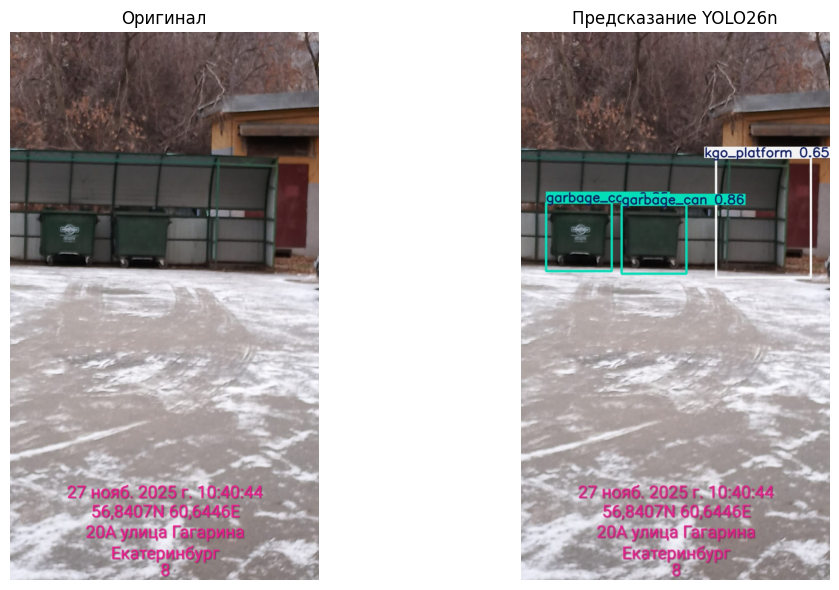


image 1/1 c:\games\!!!studyMaga\2026\PPGarbageGit\Project_Urfu_2026\datasetCreation\YoloDatasetReady\images\job48YOLOImages_2026-03-13_000342.jpg: 256x320 2 kgo_platforms, 1 garbage_can, 35.5ms
Speed: 1.9ms preprocess, 35.5ms inference, 0.5ms postprocess per image at shape (1, 3, 256, 320)


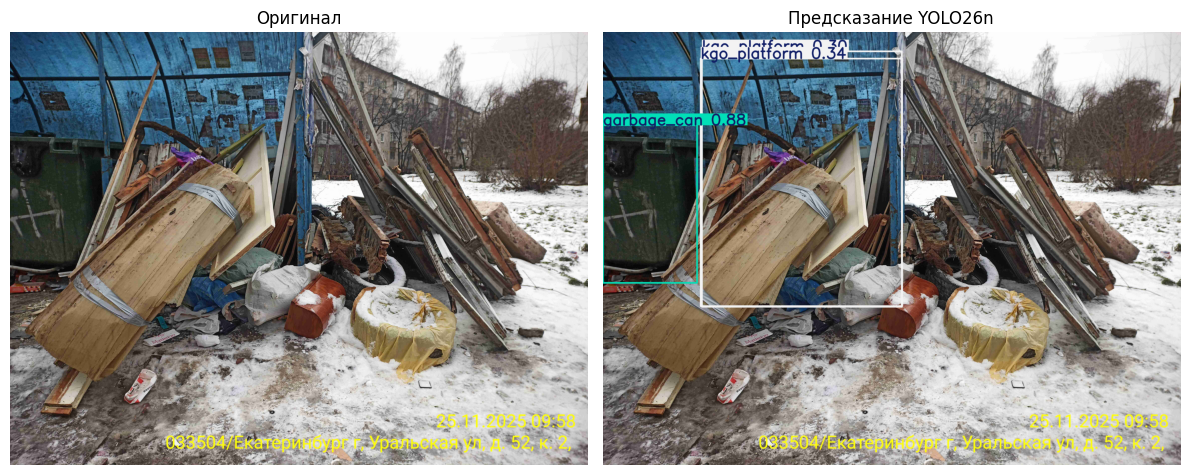


image 1/1 c:\games\!!!studyMaga\2026\PPGarbageGit\Project_Urfu_2026\datasetCreation\YoloDatasetReady\images\job39YOLOImages_TimePhoto_20251127_073856.jpg: 256x320 1 kgo_platform, 7.7ms
Speed: 1.8ms preprocess, 7.7ms inference, 1.3ms postprocess per image at shape (1, 3, 256, 320)


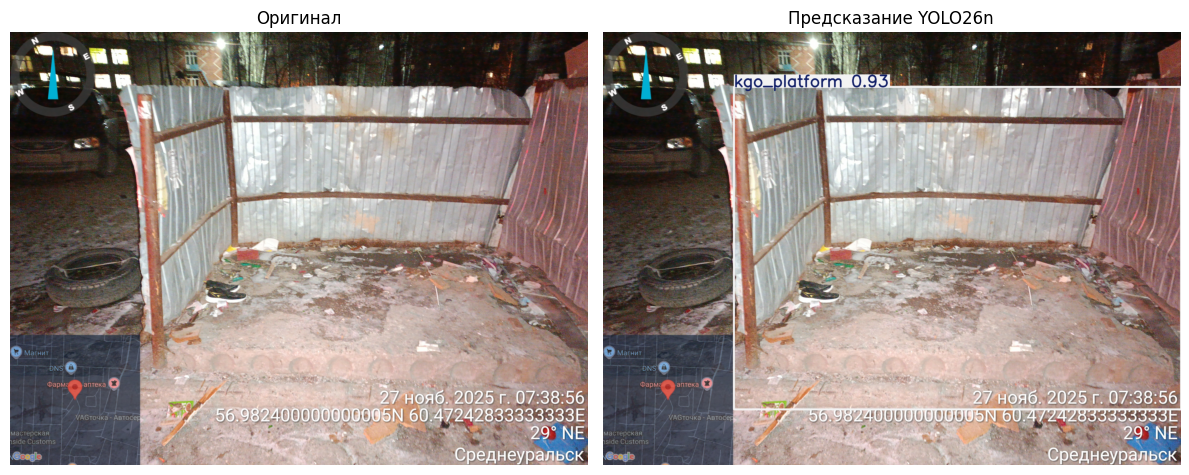

In [18]:
all_images = list((READY_DIR / "images").glob("*"))
if all_images:
    sample_imgs = random.sample(all_images, min(5, len(all_images)))
    for img_path in sample_imgs:
        results = model(str(img_path))
        save_dir = exp_dir / "predictions"
        save_dir.mkdir(exist_ok=True)
        for r in results:
            r.save(filename=str(save_dir / img_path.name))
        
        fig, axes = plt.subplots(1, 2, figsize=(12, 6))
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[0].imshow(img)
        axes[0].set_title("Оригинал")
        axes[0].axis('off')
        
        pred_img = cv2.imread(str(save_dir / img_path.name))
        pred_img = cv2.cvtColor(pred_img, cv2.COLOR_BGR2RGB)
        axes[1].imshow(pred_img)
        axes[1].set_title("Предсказание YOLO26n")
        axes[1].axis('off')
        
        plt.tight_layout()
        plt.show()
else:
    print("Изображения не найдены.")